In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Column names based on the dataset description
columns = ['unit', 'cycle', 'os1', 'os2', 'os3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Load data
train = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=columns)
test = pd.read_csv('../data/test_FD001.txt', sep=r'\s+', header=None, names=columns)
rul = pd.read_csv('../data/RUL_FD001.txt', header=None, names=['RUL'])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())

Train shape: (20631, 26)
Test shape: (13096, 26)
   unit  cycle     os1     os2    os3  sensor_1  sensor_2  sensor_3  sensor_4  \
0     1      1 -0.0007 -0.0004  100.0    518.67    641.82   1589.70   1400.60   
1     1      2  0.0019 -0.0003  100.0    518.67    642.15   1591.82   1403.14   
2     1      3 -0.0043  0.0003  100.0    518.67    642.35   1587.99   1404.20   
3     1      4  0.0007  0.0000  100.0    518.67    642.35   1582.79   1401.87   
4     1      5 -0.0019 -0.0002  100.0    518.67    642.37   1582.85   1406.22   

   sensor_5  ...  sensor_12  sensor_13  sensor_14  sensor_15  sensor_16  \
0     14.62  ...     521.66    2388.02    8138.62     8.4195       0.03   
1     14.62  ...     522.28    2388.07    8131.49     8.4318       0.03   
2     14.62  ...     522.42    2388.03    8133.23     8.4178       0.03   
3     14.62  ...     522.86    2388.08    8133.83     8.3682       0.03   
4     14.62  ...     522.19    2388.04    8133.80     8.4294       0.03   

   sensor_17 

In [8]:
train.head(10)

,unit,cycle,os1,os2,os3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [9]:
print("=== Train Info ===")
print(f"Number of engines: {train['unit'].nunique()}")
print(f"Total cycles: {len(train)}")
print(f"\nMissing values: {train.isnull().sum().sum()}")
print(f"\nCycles per engine (min/max/mean):")
cycles_per_engine = train.groupby('unit')['cycle'].max()
print(f"  Min: {cycles_per_engine.min()}")
print(f"  Max: {cycles_per_engine.max()}")
print(f"  Mean: {cycles_per_engine.mean():.1f}")

print("\n=== Basic Statistics ===")
train.describe().round(2)

=== Train Info ===
Number of engines: 100
Total cycles: 20631

Missing values: 0

Cycles per engine (min/max/mean):
  Min: 128
  Max: 362
  Mean: 206.3

=== Basic Statistics ===


,unit,cycle,os1,os2,os3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


RUL column added. Sample:
   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182


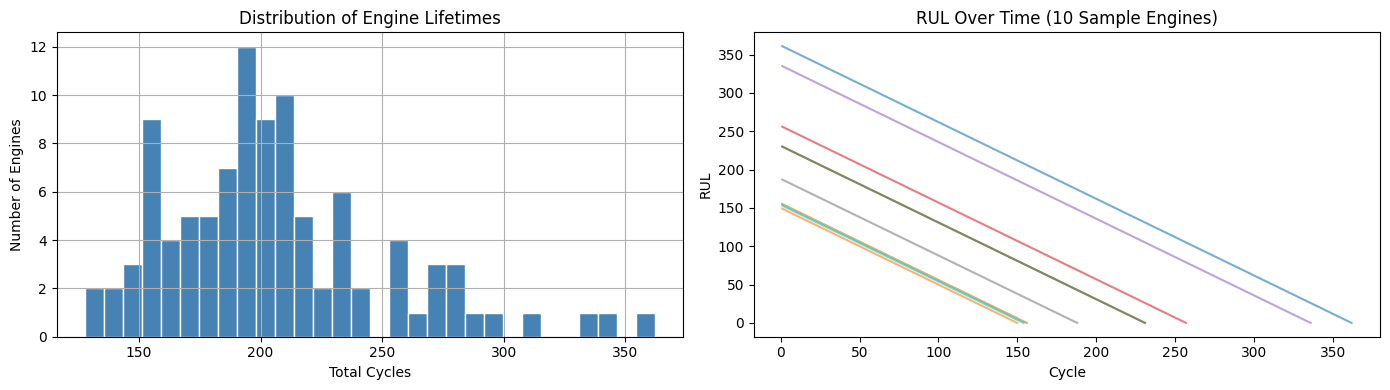

Plot saved to docs/


In [10]:
# Compute RUL for training set
# RUL = max cycle for that engine - current cycle
max_cycles = train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']
train = train.merge(max_cycles, on='unit')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop(columns=['max_cycle'], inplace=True)

print("RUL column added. Sample:")
print(train[['unit', 'cycle', 'RUL']].head(10))

# Plot RUL distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of max RUL (i.e. engine lifetime)
max_cycles['max_cycle'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Engine Lifetimes')
axes[0].set_xlabel('Total Cycles')
axes[0].set_ylabel('Number of Engines')

# RUL over time for a sample of engines
sample_engines = train['unit'].sample(10, random_state=42)
for engine in sample_engines:
    data = train[train['unit'] == engine]
    axes[1].plot(data['cycle'], data['RUL'], alpha=0.6)
axes[1].set_title('RUL Over Time (10 Sample Engines)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('RUL')

plt.tight_layout()
plt.savefig('../docs/rul_distribution.png', dpi=150)
plt.show()
print("Plot saved to docs/")

In [11]:
# Identify constant sensors (zero or near-zero variance)
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = train[sensor_cols].std().sort_values()

print("=== Sensor Standard Deviations ===")
print(sensor_std.round(4))

# Separate useful from constant sensors
constant_sensors = sensor_std[sensor_std < 0.01].index.tolist()
useful_sensors = sensor_std[sensor_std >= 0.01].index.tolist()

print(f"\nConstant sensors (will be dropped): {constant_sensors}")
print(f"\nUseful sensors (will be kept): {useful_sensors}")

=== Sensor Standard Deviations ===
sensor_1      0.0000
sensor_10     0.0000
sensor_19     0.0000
sensor_18     0.0000
sensor_16     0.0000
sensor_5      0.0000
sensor_6      0.0014
sensor_15     0.0375
sensor_8      0.0710
sensor_13     0.0719
sensor_21     0.1083
sensor_20     0.1807
sensor_11     0.2671
sensor_2      0.5001
sensor_12     0.7376
sensor_7      0.8851
sensor_17     1.5488
sensor_3      6.1311
sensor_4      9.0006
sensor_14    19.0762
sensor_9     22.0829
dtype: float64

Constant sensors (will be dropped): ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_6']

Useful sensors (will be kept): ['sensor_15', 'sensor_8', 'sensor_13', 'sensor_21', 'sensor_20', 'sensor_11', 'sensor_2', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_3', 'sensor_4', 'sensor_14', 'sensor_9']


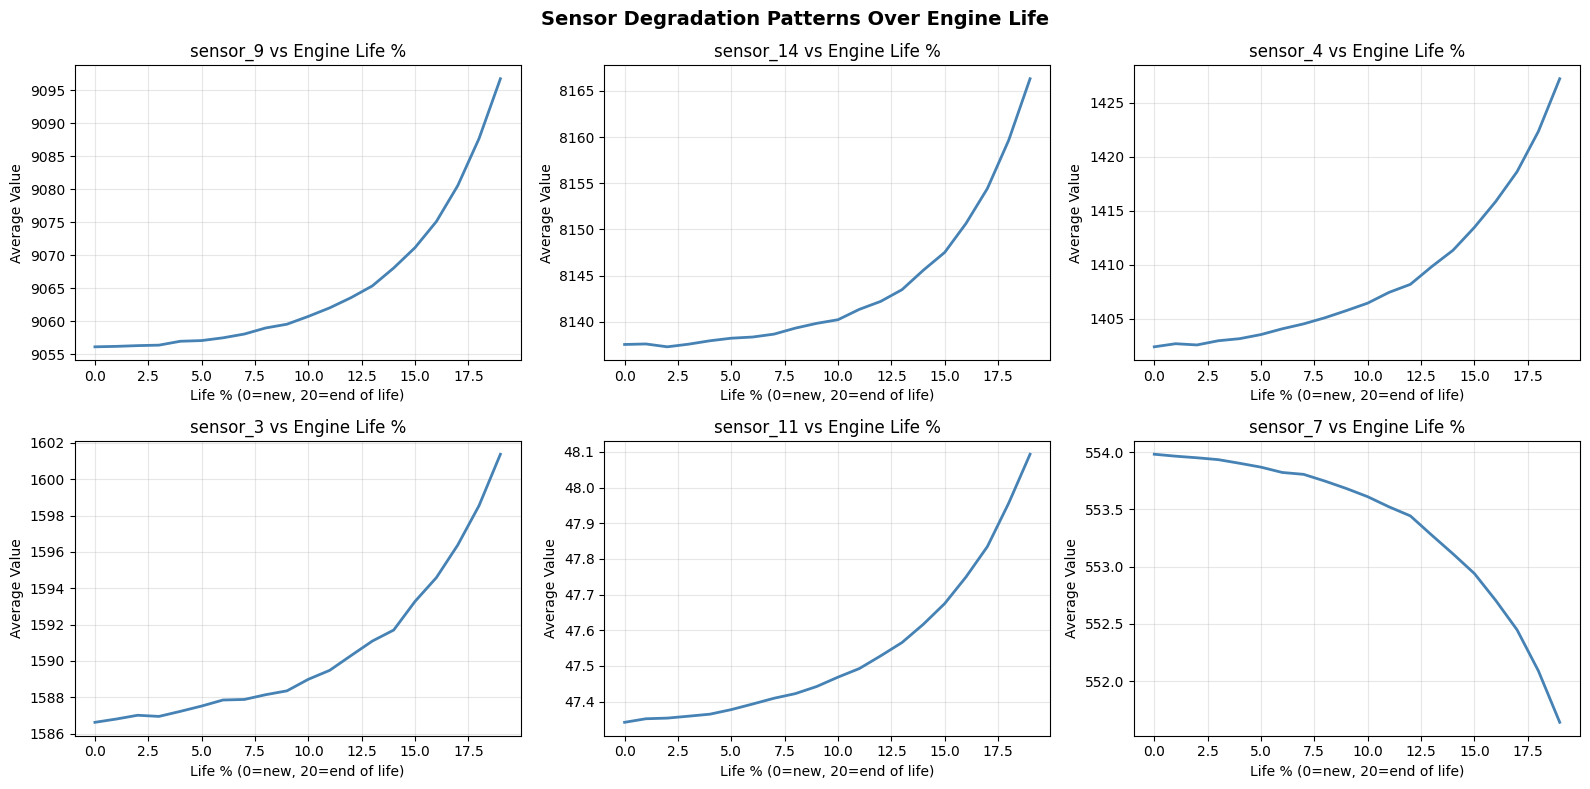

Plot saved to docs/


In [12]:
# Normalize cycle to 0-100% of engine life for fair comparison across engines
train['life_pct'] = train['cycle'] / train.groupby('unit')['cycle'].transform('max')

# Plot top sensors vs life percentage
top_sensors = ['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_11', 'sensor_7']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    # Average sensor value across all engines at each life percentage bucket
    train['life_bucket'] = pd.cut(train['life_pct'], bins=20)
    avg = train.groupby('life_bucket', observed=True)[sensor].mean()
    axes[i].plot(range(len(avg)), avg.values, color='steelblue', linewidth=2)
    axes[i].set_title(f'{sensor} vs Engine Life %')
    axes[i].set_xlabel('Life % (0=new, 20=end of life)')
    axes[i].set_ylabel('Average Value')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Sensor Degradation Patterns Over Engine Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/sensor_degradation.png', dpi=150)
plt.show()
print("Plot saved to docs/")

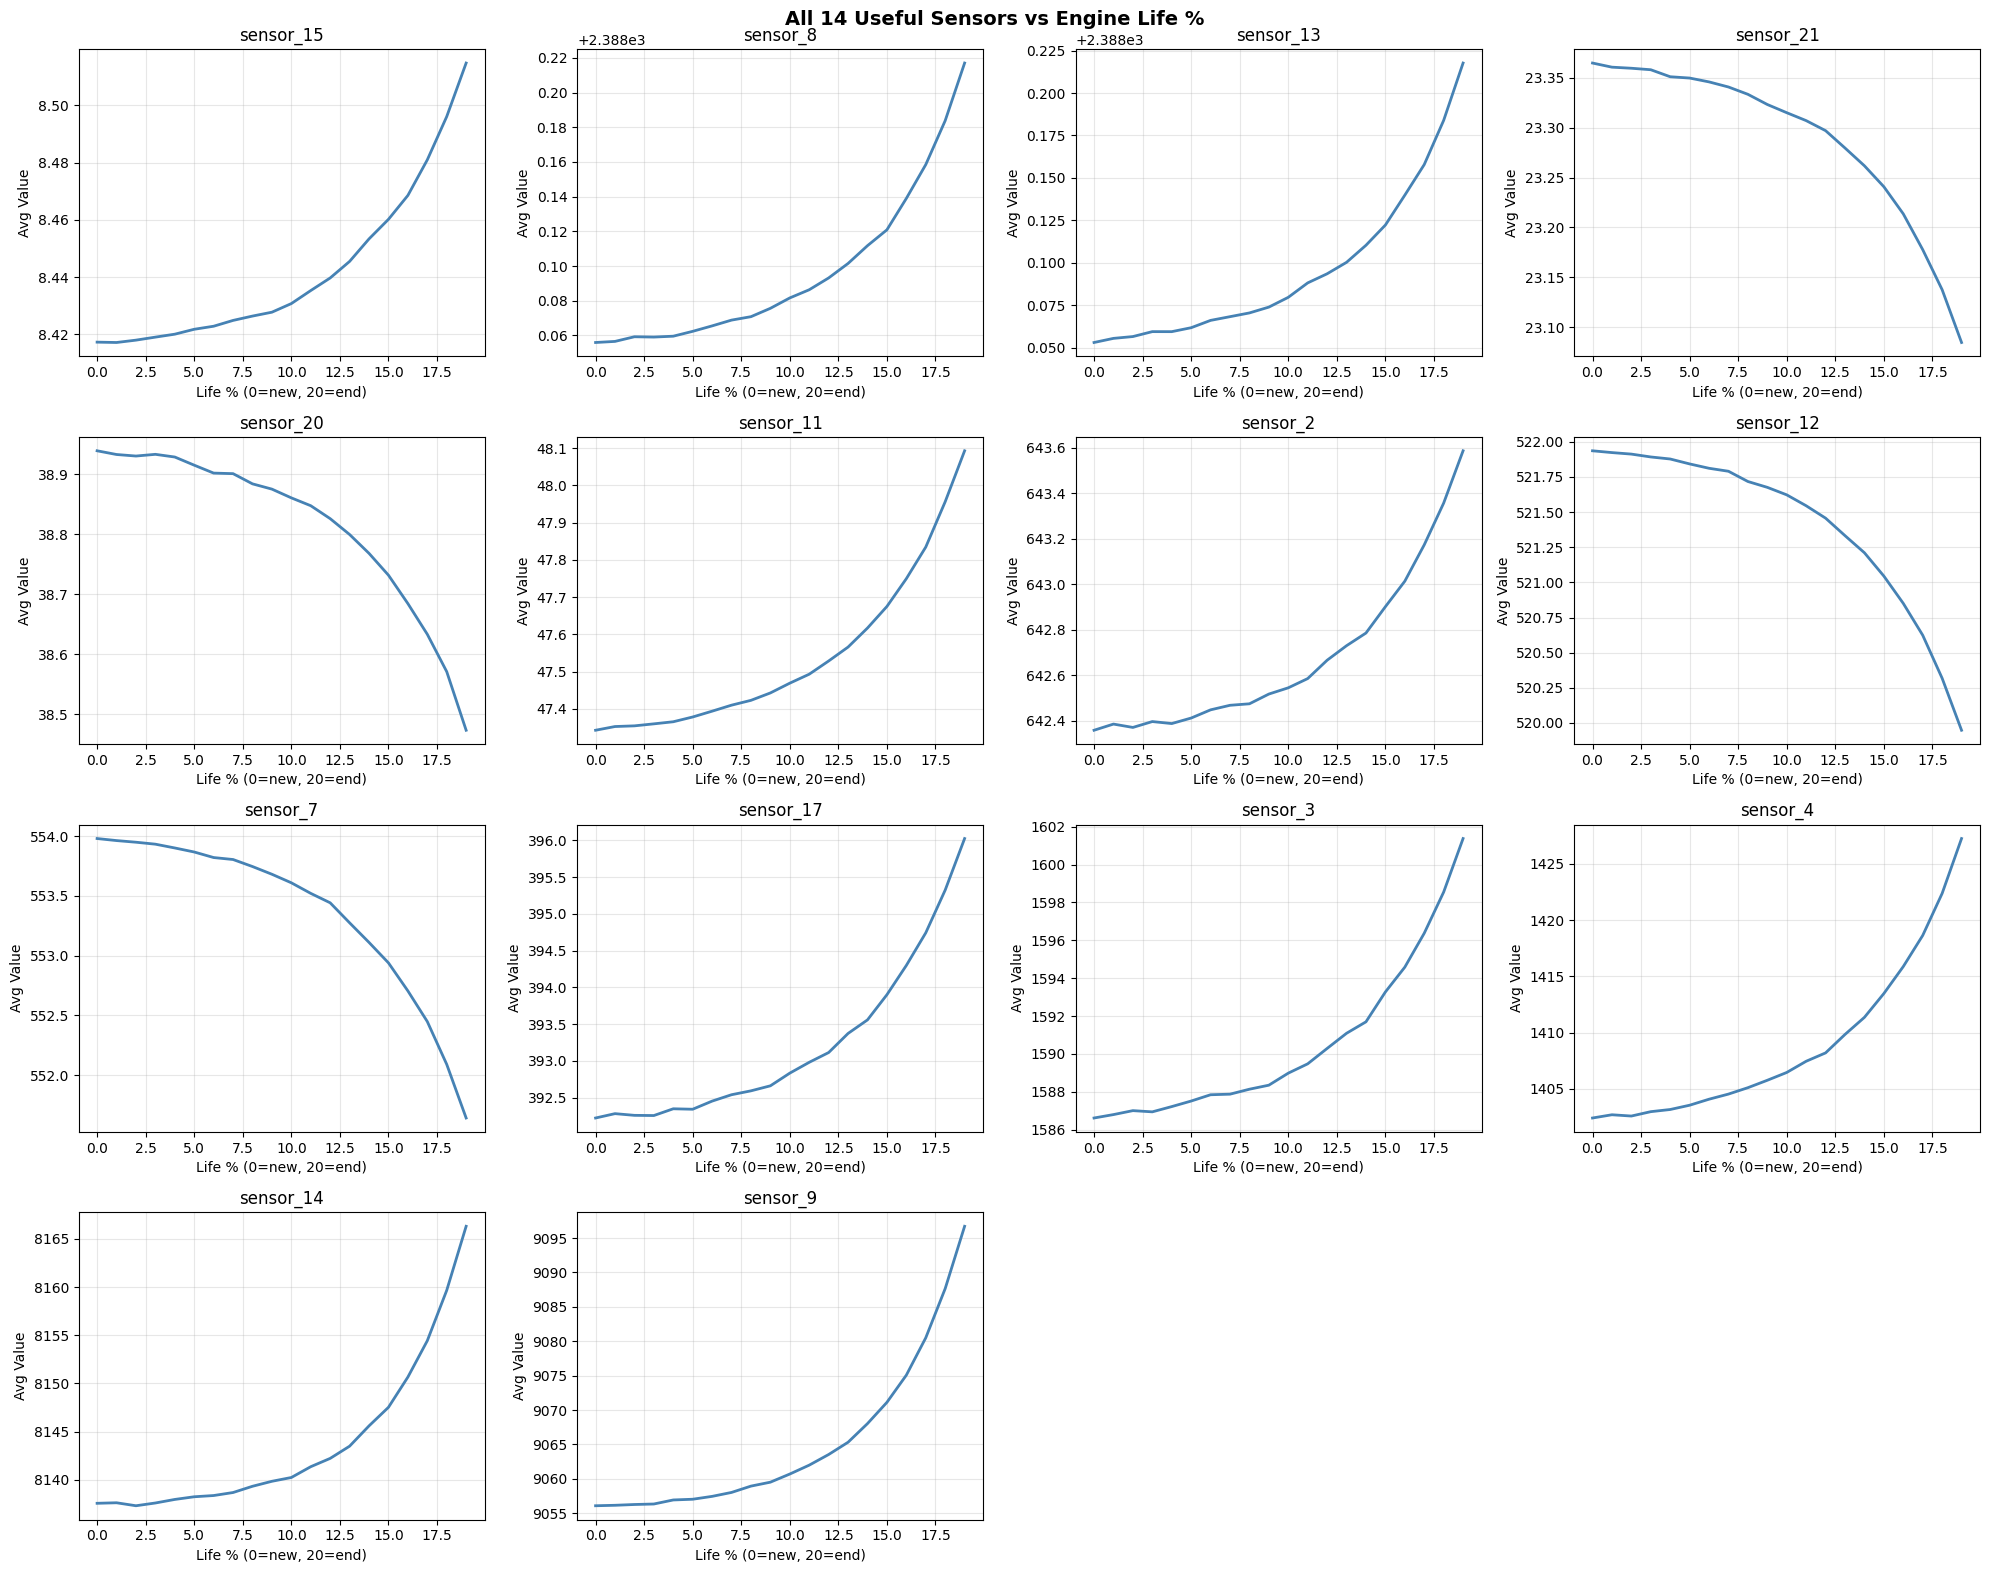

Plot saved to docs/


In [13]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors):
    train['life_bucket'] = pd.cut(train['life_pct'], bins=20)
    avg = train.groupby('life_bucket', observed=True)[sensor].mean()
    axes[i].plot(range(len(avg)), avg.values, color='steelblue', linewidth=2)
    axes[i].set_title(f'{sensor}')
    axes[i].set_xlabel('Life % (0=new, 20=end)')
    axes[i].set_ylabel('Avg Value')
    axes[i].grid(True, alpha=0.3)

# Hide the empty 15th and 16th subplots (we have 14 sensors, grid has 16 cells)
axes[14].set_visible(False)
axes[15].set_visible(False)

plt.suptitle('All 14 Useful Sensors vs Engine Life %', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/all_sensors_degradation.png', dpi=150)
plt.show()
print("Plot saved to docs/")

In [15]:
# Define and save system configuration based on EDA findings

config = {
    "useful_sensors": useful_sensors,
    "constant_sensors": constant_sensors,
    "degradation_sensors": {
        "rising": ["sensor_15", "sensor_8", "sensor_13", "sensor_11", 
                   "sensor_2", "sensor_17", "sensor_3", "sensor_4", 
                   "sensor_14", "sensor_9"],
        "falling": ["sensor_21", "sensor_20", "sensor_7", "sensor_12"]
    },
    "rul_thresholds": {
        "healthy_above": 80,
        "warning_above": 30,
        "critical_below": 30
    },
    "dataset": {
        "name": "FD001",
        "engines": 100,
        "conditions": 1,
        "fault_modes": ["HPC Degradation"]
    }
}

with open('../src/schemas/sensor_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Updated configuration saved!")
print(json.dumps(config, indent=2))

Updated configuration saved!
{
  "useful_sensors": [
    "sensor_15",
    "sensor_8",
    "sensor_13",
    "sensor_21",
    "sensor_20",
    "sensor_11",
    "sensor_2",
    "sensor_12",
    "sensor_7",
    "sensor_17",
    "sensor_3",
    "sensor_4",
    "sensor_14",
    "sensor_9"
  ],
  "constant_sensors": [
    "sensor_1",
    "sensor_10",
    "sensor_19",
    "sensor_18",
    "sensor_16",
    "sensor_5",
    "sensor_6"
  ],
  "degradation_sensors": {
    "rising": [
      "sensor_15",
      "sensor_8",
      "sensor_13",
      "sensor_11",
      "sensor_2",
      "sensor_17",
      "sensor_3",
      "sensor_4",
      "sensor_14",
      "sensor_9"
    ],
    "falling": [
      "sensor_21",
      "sensor_20",
      "sensor_7",
      "sensor_12"
    ]
  },
  "rul_thresholds": {
    "healthy_above": 80,
    "warning_above": 30,
    "critical_below": 30
  },
  "dataset": {
    "name": "FD001",
    "engines": 100,
    "conditions": 1,
    "fault_modes": [
      "HPC Degradation"
    ]
 

In [16]:
# Compute healthy baselines — mean and std of each useful sensor
# Use only early life data (first 30% of engine life) as "healthy" baseline
early_life = train[train['life_pct'] <= 0.3]

baselines = {}
for sensor in useful_sensors:
    baselines[sensor] = {
        "mean": round(float(early_life[sensor].mean()), 4),
        "std": round(float(early_life[sensor].std()), 4)
    }

with open('../src/schemas/sensor_baselines.json', 'w') as f:
    json.dump(baselines, f, indent=2)

print("Baselines saved!")
print(json.dumps(baselines, indent=2))

Baselines saved!
{
  "sensor_15": {
    "mean": 8.4188,
    "std": 0.0265
  },
  "sensor_8": {
    "mean": 2388.0588,
    "std": 0.0543
  },
  "sensor_13": {
    "mean": 2388.0576,
    "std": 0.0553
  },
  "sensor_21": {
    "mean": 23.3574,
    "std": 0.0785
  },
  "sensor_20": {
    "mean": 38.9302,
    "std": 0.13
  },
  "sensor_11": {
    "mean": 47.3582,
    "std": 0.1754
  },
  "sensor_2": {
    "mean": 642.3861,
    "std": 0.3746
  },
  "sensor_12": {
    "mean": 521.8979,
    "std": 0.4999
  },
  "sensor_7": {
    "mean": 553.9331,
    "std": 0.6217
  },
  "sensor_17": {
    "mean": 392.2837,
    "std": 1.1331
  },
  "sensor_3": {
    "mean": 1587.0093,
    "std": 4.6665
  },
  "sensor_4": {
    "mean": 1402.9046,
    "std": 5.916
  },
  "sensor_14": {
    "mean": 8137.7023,
    "std": 7.9724
  },
  "sensor_9": {
    "mean": 9056.4579,
    "std": 8.3182
  }
}
